In [54]:
# Importar y pre-procesar
import os
import numpy as np
from PIL import Image

N=1000
SIZE=(128,128)

base_dir = "./data/PetImages/"

def load_images(uri):
    filenames = [f for f in os.listdir(uri) if f.lower().endswith(".jpg")][:N]
    images = []
    for filename in filenames:
        img = Image.open(uri + filename).convert('L') # B&W
        img = img.resize(SIZE)
        images.append(np.asarray(img).flatten())
    return np.stack(images)

X = np.concatenate([load_images(base_dir + "Dog/"), load_images(base_dir + "Cat/")], axis=0)
y = np.concatenate([np.ones(N), np.zeros(N)], axis=0)

In [55]:
# Verlas
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def show_image(i, images):
    img = images[i].reshape(SIZE)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

# Example usage with your images:
interact(lambda i: show_image(i, X), i=IntSlider(min=0, max=len(X)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i', max=1999), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(i)>

In [56]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
std[std == 0] = 1 # Just in case the STD is 0
X = (X - mean) / std

In [57]:
# Dividir en train-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [1]:
# Como D >> N, usaria XX^T en vez de Cov[x], pero quiero visualizarlo a los eigenvectors
to_process = (X_train @ X_train.T) / N
eigenvals, eigenvecs = np.linalg.eigh(to_process)
# Ordenar los eigenvectors en base a los eigenvalues(mayor a menor)
idx = np.argsort(eigenvals)[::-1]
eigenvals_sorted = eigenvals[idx]
eigenvecs_sorted = eigenvecs[:,idx]

NameError: name 'X_train' is not defined

ValueError: cannot reshape array of size 1600 into shape (128,128)

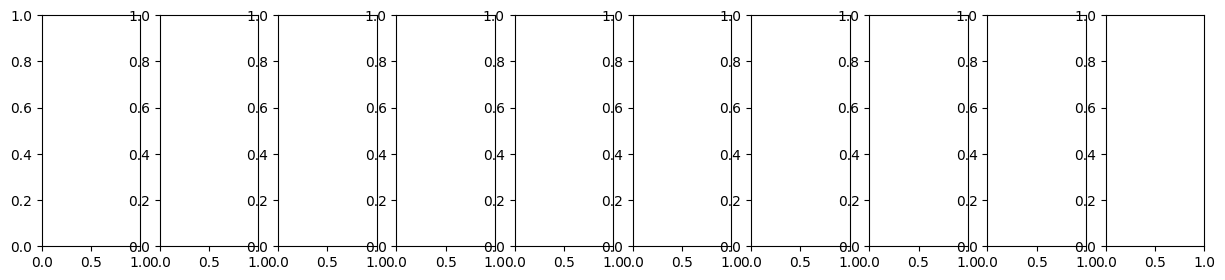

In [59]:
# Mostrar los 5 eigenvecs
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    eigen_img = eigenvecs_sorted[:, i].reshape(SIZE)
    axes[i].imshow(eigen_img, cmap='gray')
    axes[i].set_title(f"Eigenvector {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [60]:
# Mostrar las fotos re-proyectadas
def reconstruct(idx, k):
    original = X[idx]
    code = eigenvecs_sorted[:, :k]
    reconstructed = code @ (code.T @ original)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(original.reshape(SIZE), cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(reconstructed.reshape(SIZE), cmap='gray')
    axes[1].set_title(f'Reconstructed (k={k})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

interact(
    reconstruct,
    idx=IntSlider(min=0, max=N-1, step=1, value=0, description='Image'),
    k=IntSlider(min=1, max=200, step=1, value=5, description='k')
)

interactive(children=(IntSlider(value=0, description='Image', max=999), IntSlider(value=5, description='k', ma…

<function __main__.reconstruct(idx, k)>

In [70]:
# Hiperparemtros
K = 50
EPOCH = 1000
LR = 0.1
# Encodear X_train y X_test
eigens_cut = eigenvals_sorted[:, K]
la

# Regresion linear stochastic
weights = np.zeros(K)
bias = 0
for _ in range(EPOCH):
    z = X_train_code @ weights + bias
    sigmoid = 1 / (1 + np.exp(-z))

    error = sigmoid - y_train
    grad_w = (X_train_code.T @ error) / X_train_code.shape[0]
    grad_b = np.mean(error)

    weights -= LR * grad_w
    bias -= LR * grad_b

In [71]:
# Testear
def test(X, y):
    z = X @ weights + bias
    sigmoid = 1 / (1 + np.exp(-z))
    prediction = np.where(sigmoid >= 0.5, 1, 0)
    return np.mean(prediction == y)

print(test(X_test_code, y_test))

0.4375


In [72]:
# El logistic de sklearn
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=EPOCH)
logreg.fit(X_train_code, y_train)
print("Test accuracy:", logreg.score(X_test_code, y_test))

Test accuracy: 0.5275


Test accuracy: 0.5375
